# KoChatGPT 업그레이드: 데이터셋 정제·증량 + 디코딩 하이퍼파라미터 최적화

원본 KoChatGPT 파이프라인(SFT → RM → PPO, base model: `skt/kogpt2-base-v2`)을 바탕으로,
아래 두 가지 전략을 적용해 모델 성능을 개선합니다.

1. **데이터셋 정제/증량**: SFT/RM 데이터셋을 EDA하여 문제점(길이 이상치, 중복, 문장 미완성 등)을
   찾아내고 정제한 뒤, augmentation으로 데이터 크기를 복원·증량합니다.
2. **디코딩 하이퍼파라미터 서치 + 정량 평가**: Beam search / Top-k / Top-p / temperature 등
   디코딩 조합을 실험하고 BLEU, ROUGE-L, distinct-2로 정량 비교합니다.

최종적으로 제출 루브릭에 따라 아래 세 가지 비교/분석을 수행합니다.

| 비교 대상 | 목적 |
|---|---|
| 기존 KoGPT2(base) vs SFT 모델 | Instruction tuning의 효과 확인 |
| SFT(원본 데이터) vs SFT(정제+증량 데이터) | 데이터 정제 전략의 효과 확인 |
| SFT 모델 vs RM 모델 | RM이 생성 결과에 매기는 보상 점수 비교 |

> ⚠️ 본 노트북은 Colab GPU 환경(T4 이상 권장)에서 실행하는 것을 전제로 합니다.


## 0. 환경 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install datasets==4.0.0
!pip install loralib==0.1.2
!pip install trl==0.29.0
!pip install accelerate==1.13.0
!pip install transformers==4.40.0
!pip install tokenizers==0.19.1
!pip install peft==0.10.0 --no-deps
# 정량 평가를 위한 패키지
!pip install sacrebleu==2.4.2 rouge-score==0.1.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled token

In [ ]:
! git clone https://github.com/airobotlab/KoChatGPT
! cp -r /content/KoChatGPT/colossalai_ChatGPT_230319/chatgpt /content/chatgpt


Cloning into 'KoChatGPT'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 57.72 MiB | 16.73 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [ ]:
import os

# ColossalAI 의존성 제거 및 tqdm.notebook 패치 (원본 KoChatGPT 노트북과 동일)
modifications = [
    {
        "file": "chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False
    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])


✅ 수정 완료: chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: chatgpt/dataset/reward_dataset.py
⚠️ chatgpt/trainer/strategies/__init__.py 수정할 내용이 없습니다.
⚠️ chatgpt/dataset/reward_dataset.py 파일의 8번째 줄이 예상과 다릅니다.
   예상: from tqdm import tqdm
   실제: class RewardDataset(Dataset):
⚠️ chatgpt/dataset/reward_dataset.py 수정할 내용이 없습니다.


In [ ]:
import json
import copy
import random
import logging
from typing import Optional, Dict, Sequence
from dataclasses import dataclass

import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sacrebleu
from rouge_score import rouge_scorer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch version:", torch.__version__)
print("Cuda available:", torch.cuda.is_available())
print("transformers version:", transformers.__version__)

SEED = 230319
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Torch version: 2.11.0+cu128
Cuda available: True
transformers version: 4.40.0


## 1. 기존 KoGPT2(base) 로드

가장 먼저 SFT를 적용하지 **않은** `skt/kogpt2-base-v2` 모델을 그대로 로드해 생성 결과를 확보합니다.
이 결과는 이후 "기존 KoGPT2 vs SFT 모델" 비교의 기준점(baseline)이 됩니다.


In [ ]:
BASE_MODEL_NAME = "skt/kogpt2-base-v2"

base_tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_NAME, bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right", model_max_length=512,
)
base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME).to(device)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

# 학습/평가에 일관되게 사용할 테스트 프롬프트
TEST_PROMPTS_RAW = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어?',
    '오늘 미세먼지 어때?',
]
TEST_PROMPTS = [PROMPT_DICT['prompt_input'].format_map({'prompt': p}) for p in TEST_PROMPTS_RAW]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

In [ ]:
def generate_once(model, tokenizer, prompt_text, **gen_kwargs):
    input_ids = tokenizer(prompt_text, return_tensors='pt')['input_ids'].to(device)
    with torch.no_grad():
        output = model.generate(input_ids, pad_token_id=tokenizer.pad_token_id, **gen_kwargs)
    text = tokenizer.decode(output[0], skip_special_tokens=True)
    return text

print("=" * 80)
print("[기존 KoGPT2(base) 생성 결과 - greedy decoding]")
print("=" * 80)
for prompt in TEST_PROMPTS:
    result = generate_once(base_model, base_tokenizer, prompt, max_new_tokens=64, do_sample=False)
    print(result)
    print("-" * 80)


[기존 KoGPT2(base) 생성 결과 - greedy decoding]
### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):
###############################################################
--------------------------------------------------------------------------------
### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):
###############################################################
--------------------------------------------------------------------------------
### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):
###############################################################
--------------------------------------------------------------------------------
### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):
###############################################################
--------------------------------------------------------------------------------


## 2. 데이터셋 로드 및 EDA

`KoChatGPT`가 제공하는 세 데이터셋(SFT/RM/PPO)을 로드하고, 다음 관점에서 EDA를 수행합니다.

- **길이 분포**: prompt / completion의 어절(word) 길이 분포와 이상치
- **중복**: 완전히 동일한 prompt-completion 쌍이 존재하는지
- **문장 완성도**: completion이 문장부호(`.`, `?`, `!`, `다`, `요` 등)로 자연스럽게 끝나는지
- **반복(degeneration)**: 동일 어절/구문이 비정상적으로 반복되는지


In [ ]:
DATA_DIR = 'KoChatGPT/data_kochatgpt'

with open(f'{DATA_DIR}/kochatgpt_1_SFT.jsonl', 'r', encoding='utf-8-sig') as f:
    sft_data_raw = json.load(f)

with open(f'{DATA_DIR}/kochatgpt_2_RM.jsonl', 'r', encoding='utf-8-sig') as f:
    rm_data_raw = json.load(f)

with open(f'{DATA_DIR}/kochatgpt_3_PPO.jsonl', 'r', encoding='utf-8-sig') as f:
    ppo_data_raw = json.load(f)

print('SFT 데이터 개수:', len(sft_data_raw))
print('RM  데이터 개수:', len(rm_data_raw))
print('PPO 데이터 개수:', len(ppo_data_raw))


SFT 데이터 개수: 12000
RM  데이터 개수: 10220
PPO 데이터 개수: 12000


/tmp/ipykernel_1294/2335137114.py:14: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1294/2335137114.py:14: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1294/2335137114.py:14: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1294/2335137114.py:14: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1294/2335137114.py:14: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1294/2335137114.py:14: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from fon

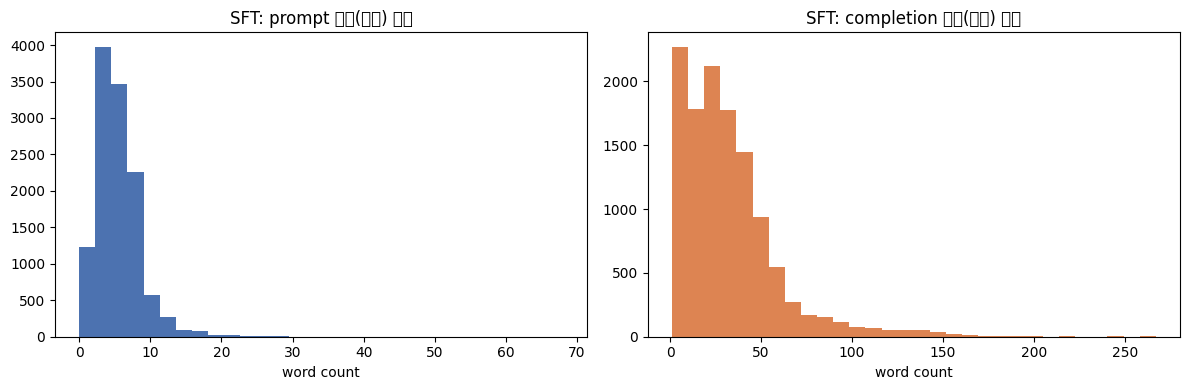

count    12000.000000
mean         5.532583
std          3.295048
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         68.000000
dtype: float64

count    12000.000000
mean        32.436417
std         27.691404
min          1.000000
25%         13.000000
50%         27.000000
75%         43.000000
max        267.000000
dtype: float64


In [ ]:
def word_len(text):
    return len(text.strip().split())

sft_prompt_lens = [word_len(d['prompt']) for d in sft_data_raw]
sft_completion_lens = [word_len(d['completion']) for d in sft_data_raw]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sft_prompt_lens, bins=30, color='#4C72B0')
axes[0].set_title('SFT: prompt 길이(어절) 분포')
axes[0].set_xlabel('word count')
axes[1].hist(sft_completion_lens, bins=30, color='#DD8452')
axes[1].set_title('SFT: completion 길이(어절) 분포')
axes[1].set_xlabel('word count')
plt.tight_layout()
plt.show()

print(pd.Series(sft_prompt_lens).describe())
print()
print(pd.Series(sft_completion_lens).describe())


In [ ]:
# 중복 확인
sft_pairs = [(d['prompt'], d['completion']) for d in sft_data_raw]
n_dup = len(sft_pairs) - len(set(sft_pairs))
print(f'완전 중복 (prompt, completion) 쌍 개수: {n_dup}')

# 문장 완성도 확인: 한국어 종결어미/문장부호로 끝나는지 대략적으로 체크
import re
END_PATTERN = re.compile(r'(다|요|까|죠|네|음|함|임)[\.!?]?$|[\.!?]$')

def is_complete_sentence(text):
    text = text.strip()
    if len(text) == 0:
        return False
    return bool(END_PATTERN.search(text))

incomplete_flags = [not is_complete_sentence(d['completion']) for d in sft_data_raw]
print(f'문장이 자연스럽게 끝나지 않는 completion 비율: {sum(incomplete_flags) / len(incomplete_flags):.2%}')

# 예시 출력
print()
print('[문장 미완성으로 판단된 예시 3개]')
shown = 0
for d, flag in zip(sft_data_raw, incomplete_flags):
    if flag:
        print('-', d['completion'])
        shown += 1
    if shown >= 3:
        break


완전 중복 (prompt, completion) 쌍 개수: 0
문장이 자연스럽게 끝나지 않는 completion 비율: 6.32%

[문장 미완성으로 판단된 예시 3개]
- "요? 불분명한 질문으로 보입니다. '프레스턴 브룩스'란 인물이 어느 나라의 의원을 역임했는지, 어떤 의회의 의원이었는지 등의 정보가 필요합니다. 이에 대한 정보를 제공해 주시면 더 정확한 답변을 드릴 수 있습니다.", 'token': 154}
- '> "I am thirsty." (English) \n\n> "Je suis assoiffé." (French) \n\n> "Tengo sed." (Spanish) \n\n> "Ich bin durstig." (German) \n\n> "나는 목이 마르다." (Korean)
- "한명숙 장관이 리더쉽 평가에서 1위로 선정된 신문은 '조선일보'입니다.", 'token': 85}


In [ ]:
# 반복(degeneration) 체크: completion 내 동일 3-gram(어절 단위)이 과도하게 반복되는지
def max_ngram_repeat_ratio(text, n=3):
    words = text.strip().split()
    if len(words) < n + 1:
        return 0.0
    ngrams = [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]
    if not ngrams:
        return 0.0
    counts = pd.Series(ngrams).value_counts()
    return counts.max() / len(ngrams)

repeat_ratios = [max_ngram_repeat_ratio(d['completion']) for d in sft_data_raw]
print(pd.Series(repeat_ratios).describe())
print(f'3-gram 반복 비율 0.5 이상인 샘플 수: {sum(r >= 0.5 for r in repeat_ratios)}')


count    12000.000000
mean         0.072226
std          0.093891
min          0.000000
25%          0.023810
50%          0.038462
75%          0.071429
max          0.500000
dtype: float64
3-gram 반복 비율 0.5 이상인 샘플 수: 270


## 3. 데이터 정제

EDA 결과를 바탕으로 아래 규칙으로 SFT/RM 데이터셋을 정제합니다.

1. **길이 필터링**: completion이 너무 짧으면(2어절 미만) 정보량이 부족하고, 너무 길면(95th
   percentile 초과) 이상치일 가능성이 높으므로 제거
2. **중복 제거**: 동일한 (prompt, completion) 쌍 제거
3. **문장 완성도 필터링**: 자연스러운 종결어미/문장부호로 끝나지 않는 completion 제거
4. **반복(degeneration) 필터링**: 3-gram 반복 비율이 0.5 이상인 completion 제거

RM 데이터셋은 (chosen, rejected) 랭킹 구조를 유지해야 하므로, prompt 자체가 위 기준에 걸리는
경우에만 그 프롬프트에 대한 항목 전체를 제거합니다.


In [ ]:
def clean_sft_data(data_list):
    lens = [word_len(d['completion']) for d in data_list]
    upper_bound = np.percentile(lens, 95)
    lower_bound = 2

    seen = set()
    cleaned = []
    stats = {'too_short_or_long': 0, 'duplicate': 0, 'incomplete': 0, 'repetitive': 0}

    for d in data_list:
        key = (d['prompt'], d['completion'])
        length = word_len(d['completion'])

        if length < lower_bound or length > upper_bound:
            stats['too_short_or_long'] += 1
            continue
        if key in seen:
            stats['duplicate'] += 1
            continue
        if not is_complete_sentence(d['completion']):
            stats['incomplete'] += 1
            continue
        if max_ngram_repeat_ratio(d['completion']) >= 0.5:
            stats['repetitive'] += 1
            continue

        seen.add(key)
        cleaned.append(d)

    return cleaned, stats

sft_data_cleaned, clean_stats = clean_sft_data(sft_data_raw)

print(f'정제 전: {len(sft_data_raw)}개  ->  정제 후: {len(sft_data_cleaned)}개')
print('제거 사유별 개수:', clean_stats)


정제 전: 12000개  ->  정제 후: 10226개
제거 사유별 개수: {'too_short_or_long': 810, 'duplicate': 0, 'incomplete': 713, 'repetitive': 251}


In [ ]:
def clean_rm_data(data_list):
    """RM 데이터는 prompt당 completion_0/1의 (chosen, rejected) 랭킹 구조를 유지해야 하므로,
    두 completion 중 하나라도 기준에 걸리면 해당 prompt 항목 전체를 제거한다."""
    cleaned = []
    removed = 0
    for d in data_list:
        completions = [d['completion_0'], d['completion_1']]
        ok = True
        for c in completions:
            length = word_len(c)
            if length < 2 or not is_complete_sentence(c) or max_ngram_repeat_ratio(c) >= 0.5:
                ok = False
                break
        if ok:
            cleaned.append(d)
        else:
            removed += 1
    return cleaned, removed

rm_data_cleaned, rm_removed = clean_rm_data(rm_data_raw)
print(f'RM 데이터 정제 전: {len(rm_data_raw)}개  ->  정제 후: {len(rm_data_cleaned)}개 (제거 {rm_removed}개)')


RM 데이터 정제 전: 10220개  ->  정제 후: 3953개 (제거 6267개)


## 4. Train / Eval 분할

정량 평가(BLEU/ROUGE)를 위해서는 학습에 쓰이지 않은 held-out 참조(reference) completion이
필요합니다. **Augmentation을 적용하기 전에** 먼저 정제된 데이터를 train/eval로 분할하고,
eval set은 이후 어떤 augmentation도 적용하지 않습니다. (평가 데이터 누수 방지)


In [ ]:
random.shuffle(sft_data_cleaned)

N_EVAL = 100
sft_eval = sft_data_cleaned[:N_EVAL]
sft_train_clean = sft_data_cleaned[N_EVAL:]

print(f'정제 데이터 중 학습용: {len(sft_train_clean)}개, 평가용(held-out): {len(sft_eval)}개')

# 원본(정제 전) 데이터도 동일한 eval 프롬프트를 제외한 나머지를 baseline 학습에 사용
eval_keys = set((d['prompt'], d['completion']) for d in sft_eval)
sft_train_original = [d for d in sft_data_raw if (d['prompt'], d['completion']) not in eval_keys]
print(f'원본(baseline) 학습 데이터: {len(sft_train_original)}개')


정제 데이터 중 학습용: 10126개, 평가용(held-out): 100개
원본(baseline) 학습 데이터: 11900개


## 5. Augmentation (EDA: Easy Data Augmentation)

정제 과정에서 줄어든 데이터 크기를 보완하기 위해 어절 단위의 간단한 EDA 기법
(Random Deletion, Random Swap)을 적용합니다.

**주의(caveat)**: EDA는 원래 텍스트 분류 태스크를 위해 제안된 기법으로, 노이즈를 추가해도
레이블(class)이 바뀌지 않는다는 전제가 있습니다. 하지만 SFT는 **생성(generation)** 태스크이므로
completion에 노이즈를 과하게 주면 문장이 비문이 되어 오히려 학습에 해가 될 수 있습니다.
따라서:

- **prompt는 그대로 유지**하고 **completion에만** 매우 낮은 확률(`p=0.1`)로 적용
- 원본 데이터도 함께 유지 (완전히 대체하지 않고 추가)해 노이즈의 영향력을 희석
- 문장 길이가 3어절 미만이면 augmentation을 건너뜀 (과도한 손상 방지)

이렇게 만든 augmented 샘플들은 어디까지나 정제로 줄어든 데이터양을 보완하기 위한 보조 수단이며,
정제 자체의 효과(품질 향상)와 증량 효과(양적 보완)를 분리해서 해석할 수 있도록 이후 비교 실험에서
"정제만" vs "정제+증량"을 함께 확인합니다.


In [ ]:
def random_deletion(words, p=0.1):
    if len(words) == 1:
        return words
    new_words = [w for w in words if random.random() > p]
    if len(new_words) == 0:
        return [random.choice(words)]
    return new_words

def random_swap(words, n_swap=1):
    words = words.copy()
    for _ in range(n_swap):
        if len(words) < 2:
            break
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return words

def eda_augment(text, p=0.1):
    words = text.strip().split()
    if len(words) < 3:
        return text  # 너무 짧으면 손상 위험이 크므로 스킵
    words = random_deletion(words, p=p)
    words = random_swap(words, n_swap=1)
    return ' '.join(words)

def augment_sft_data(data_list, p=0.1, seed=SEED):
    rng = random.Random(seed)
    augmented = []
    for d in data_list:
        aug_completion = eda_augment(d['completion'], p=p)
        if aug_completion != d['completion']:
            augmented.append({'prompt': d['prompt'], 'completion': aug_completion})
    return augmented

sft_augmented = augment_sft_data(sft_train_clean, p=0.1)
sft_train_refined = sft_train_clean + sft_augmented

print(f'정제된 학습 데이터: {len(sft_train_clean)}개')
print(f'augmentation으로 추가된 데이터: {len(sft_augmented)}개')
print(f'정제+증량 최종 학습 데이터: {len(sft_train_refined)}개  (원본 학습 데이터 {len(sft_train_original)}개와 비교)')

print()
print('[augmentation 예시]')
for orig, aug in zip(sft_train_clean[:3], sft_augmented[:3]):
    print('원본  :', orig['completion'])
    print('증강  :', aug['completion'])
    print('-' * 60)


정제된 학습 데이터: 10126개
augmentation으로 추가된 데이터: 9980개
정제+증량 최종 학습 데이터: 20106개  (원본 학습 데이터 11900개와 비교)

[augmentation 예시]
원본  : '저는 인공지능 챗봇이므로 과거 또는 현재의 정보를 알 수 없으나, 비와코 익스프레스의 운행시간은 해당 기업이나 관련 기관에서 확인하시면 됩니다. 일반적으로 기차 운행시간은 요일, 구간, 계절 등에 따라 다를 수 있으므로 정확한 정보를 확인하는 것이 중요합니다.
증강  : '저는 인공지능 비와코 과거 또는 현재의 정보를 알 수 없으나, 챗봇이므로 해당 기업이나 관련 기관에서 확인하시면 일반적으로 기차 운행시간은 구간, 계절 등에 따라 다를 수 있으므로 정보를 확인하는 것이 중요합니다.
------------------------------------------------------------
원본  : 'I got angry and vented my frustration over the phone.
증강  : 'I got angry and vented my frustration over phone. the
------------------------------------------------------------
원본  : '일본 여객철도의 전동차 중에서 차체 구조에 외판 자체의 강도를 높이는 공법이 적용된 것은 "EF510 형 전기기관차"입니다. 이 기관차는 높은 속도와 중량을 지탱하기 위해 차체 구조가 튼튼하게 제작되어 있습니다.
증강  : '일본 여객철도의 전동차 중에서 차체 구조에 자체의 강도를 높이는 공법이 적용된 높은 "EF510 형 전기기관차"입니다. 이 기관차는 것은 속도와 중량을 지탱하기 위해 차체 구조가 튼튼하게 제작되어 있습니다.
------------------------------------------------------------


## 6. SFT Dataset / Collator

원본 KoChatGPT의 `SFT_dataset` 클래스를 거의 그대로 사용하되, 파일 경로 대신 **메모리상의
리스트**를 직접 받을 수 있도록 수정합니다. (baseline / refined 두 버전의 데이터를 파일로 매번
저장하지 않고 바로 학습에 사용하기 위함)


In [ ]:
class SFT_dataset(Dataset):
    def __init__(self, list_data_dict, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_output = 'completion'

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }
        prompt_input = PROMPT_DICT["prompt_input"]

        sources = [prompt_input.format_map(example) for example in list_data_dict]
        targets = [f"{example[pattern_output]}{tokenizer.eos_token}" for example in list_data_dict]
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)
        examples_tokenized = self._tokenize_fn(examples, tokenizer)

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100

        self.input_ids = input_ids
        self.labels = labels
        logging.warning("Loading data done!!: %d" % (len(self.labels)))

    def _tokenize_fn(self, strings, tokenizer):
        tokenized_list = [
            tokenizer(text, return_tensors="pt", padding="longest",
                       max_length=tokenizer.model_max_length, truncation=True)
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(input_ids=input_ids, labels=labels,
                    input_ids_lens=input_ids_lens, labels_lens=labels_lens)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, i):
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])


@dataclass
class DataCollatorForSupervisedDataset(object):
    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances):
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=-100)
        return dict(
            input_ids=input_ids, labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )


## 7. SFT 학습: 원본 데이터 vs 정제+증량 데이터

동일한 하이퍼파라미터(원본 노트북과 동일: 1 epoch, batch size 8)로 두 모델을 각각 학습합니다.

- `models/output_1_SFT_baseline` : 원본(정제 전) 데이터로 학습
- `models/output_1_SFT_refined`  : 정제+증량 데이터로 학습

두 모델 모두 동일한 held-out eval set(`sft_eval`)으로 이후 정량 평가합니다.


In [ ]:
def train_sft(list_data_dict, output_dir, num_train_epochs=1):
    tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL_NAME, bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
        padding_side="right", model_max_length=512,
    )
    model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME)

    train_dataset = SFT_dataset(list_data_dict, tokenizer)
    data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

    training_args = transformers.TrainingArguments(
        output_dir="test_" + output_dir.split('/')[-1],
        overwrite_output_dir=True,
        num_train_epochs=num_train_epochs,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=5,
        prediction_loss_only=True,
        fp16=True,
        report_to="none",
    )
    trainer = transformers.Trainer(
        model=model, args=training_args,
        data_collator=data_collator, train_dataset=train_dataset,
    )
    trainer.train()
    model.save_pretrained(output_dir)
    return model, tokenizer

print('=== SFT baseline(원본 데이터) 학습 시작 ===')
sft_baseline_model, sft_tokenizer = train_sft(sft_train_original, 'models/output_1_SFT_baseline')
torch.cuda.empty_cache()


=== SFT baseline(원본 데이터) 학습 시작 ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Step,Training Loss
500,2.968900
1000,2.768100


In [ ]:
print('=== SFT refined(정제+증량 데이터) 학습 시작 ===')
sft_refined_model, _ = train_sft(sft_train_refined, 'models/output_1_SFT_refined')
torch.cuda.empty_cache()


=== SFT refined(정제+증량 데이터) 학습 시작 ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Step,Training Loss
500,3.366500
1000,3.145600
1500,2.964300
2000,2.856700
2500,2.805400


## 8. 정량 평가 함수 정의

- **BLEU**: `sacrebleu`의 문자 단위(`tokenize='char'`) 토크나이저 사용. 한국어는 형태소 단위
  분석기(예: OKT, Mecab)를 쓰는 것이 이상적이나, 외부 형태소 분석기 설치 없이도 안정적으로
  계산 가능한 문자 단위 BLEU를 기본으로 채택합니다. (참고: 이전 프로젝트에서 어절 단위 분할이
  BLEU 점수를 낮게 만들 수 있다는 점을 이미 확인한 바 있어, 여기서는 문자 단위로 일관성을 둡니다.)
- **ROUGE-L**: `rouge_score` 라이브러리의 LCS 기반 ROUGE-L F1
- **distinct-2**: 생성 결과 전체에서 유니크한 2-gram 비율 (반복/단조로움 정도를 나타내는 다양성 지표)


In [ ]:
_rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)

def compute_bleu(hypotheses, references):
    bleu = sacrebleu.corpus_bleu(hypotheses, [references], tokenize='char')
    return bleu.score

def compute_rouge_l(hypotheses, references):
    scores = [_rouge.score(ref, hyp)['rougeL'].fmeasure for hyp, ref in zip(hypotheses, references)]
    return float(np.mean(scores))

def compute_distinct_2(hypotheses):
    all_bigrams = []
    for text in hypotheses:
        chars = list(text.replace(' ', ''))
        bigrams = list(zip(chars, chars[1:]))
        all_bigrams.extend(bigrams)
    if not all_bigrams:
        return 0.0
    return len(set(all_bigrams)) / len(all_bigrams)


In [ ]:
def generate_response(model, tokenizer, prompt_raw, gen_kwargs):
    prompt_text = PROMPT_DICT['prompt_input'].format_map({'prompt': prompt_raw})
    input_ids = tokenizer(prompt_text, return_tensors='pt')['input_ids'].to(device)
    with torch.no_grad():
        output = model.generate(input_ids, pad_token_id=tokenizer.pad_token_id, **gen_kwargs)
    full_text = tokenizer.decode(output[0], skip_special_tokens=True)
    # prompt 이후 생성된 response 부분만 추출
    response = full_text.split('### Response(응답):')[-1].strip()
    return response


## 9. 디코딩 하이퍼파라미터 그리드 서치

아래 조합들을 held-out eval set의 일부(속도를 위해 20개 샘플)에 대해 생성해보고, BLEU/ROUGE-L/
distinct-2로 비교합니다. 두 모델(baseline, refined) 모두에 동일한 그리드를 적용합니다.


In [ ]:
DECODING_GRID = {
    'greedy': dict(do_sample=False, max_new_tokens=64),
    'beam4': dict(do_sample=False, num_beams=4, no_repeat_ngram_size=3, max_new_tokens=64),
    'beam8_rep1.3': dict(do_sample=False, num_beams=8, no_repeat_ngram_size=3,
                         repetition_penalty=1.3, max_new_tokens=64),
    'topk50': dict(do_sample=True, top_k=50, max_new_tokens=64),
    'topp0.92': dict(do_sample=True, top_p=0.92, top_k=0, max_new_tokens=64),
    'topk50_temp0.7': dict(do_sample=True, top_k=50, temperature=0.7, max_new_tokens=64),
}

GRID_SEARCH_N = 20
grid_eval_samples = sft_eval[:GRID_SEARCH_N]
grid_refs = [d['completion'] for d in grid_eval_samples]
grid_prompts = [d['prompt'] for d in grid_eval_samples]

def run_decoding_grid(model, tokenizer, model_label):
    rows = []
    for config_name, gen_kwargs in DECODING_GRID.items():
        torch.manual_seed(SEED)  # 샘플링 디코딩 재현성 확보
        hyps = [generate_response(model, tokenizer, p, gen_kwargs) for p in grid_prompts]
        bleu = compute_bleu(hyps, grid_refs)
        rouge_l = compute_rouge_l(hyps, grid_refs)
        distinct2 = compute_distinct_2(hyps)
        rows.append({
            'model': model_label, 'decoding': config_name,
            'BLEU': bleu, 'ROUGE-L': rouge_l, 'distinct-2': distinct2,
        })
    return rows

grid_rows = []
grid_rows += run_decoding_grid(sft_baseline_model, sft_tokenizer, 'SFT_baseline')
grid_rows += run_decoding_grid(sft_refined_model, sft_tokenizer, 'SFT_refined')

grid_df = pd.DataFrame(grid_rows)
grid_df = grid_df.sort_values(['model', 'BLEU'], ascending=[True, False])
grid_df


,model,decoding,BLEU,ROUGE-L,distinct-2
0,SFT_baseline,greedy,15.441325,0.087500,0.379472
5,SFT_baseline,topk50_temp0.7,15.364708,0.070000,0.531856
3,SFT_baseline,topk50,14.422675,0.050000,0.590650
2,SFT_baseline,beam8_rep1.3,14.326582,0.025000,0.315957
1,SFT_baseline,beam4,13.815444,0.089286,0.401698
4,SFT_baseline,topp0.92,10.620323,0.000000,0.639916
6,SFT_refined,greedy,17.542965,0.100000,0.397227
7,SFT_refined,beam4,17.336699,0.100000,0.438659
11,SFT_refined,topk50_temp0.7,16.773570,0.033333,0.514943
8,SFT_refined,beam8_rep1.3,13.341409,0.106667,0.355108


In [ ]:
# 모델별 최적 디코딩 설정 선택 (BLEU 기준)
best_config_per_model = {}
for model_label in ['SFT_baseline', 'SFT_refined']:
    sub = grid_df[grid_df['model'] == model_label]
    best_row = sub.loc[sub['BLEU'].idxmax()]
    best_config_per_model[model_label] = best_row['decoding']
    print(f"{model_label} 최적 디코딩 설정: {best_row['decoding']} "
          f"(BLEU={best_row['BLEU']:.2f}, ROUGE-L={best_row['ROUGE-L']:.3f}, distinct-2={best_row['distinct-2']:.3f})")


SFT_baseline 최적 디코딩 설정: greedy (BLEU=15.44, ROUGE-L=0.087, distinct-2=0.379)
SFT_refined 최적 디코딩 설정: greedy (BLEU=17.54, ROUGE-L=0.100, distinct-2=0.397)


## 10. 최종 비교: 기존 KoGPT2 vs SFT(원본) vs SFT(정제+증량)

각 모델에 대해 (모델이 SFT라면) 그리드 서치에서 찾은 최적 디코딩 설정을 적용하고, 전체
held-out eval set(`sft_eval`, 100개)에 대해 정량 평가합니다. 기존 KoGPT2(base)는 instruction
tuning이 되어 있지 않으므로 동일한 greedy 설정으로 비교 기준을 맞춥니다.


In [ ]:
full_refs = [d['completion'] for d in sft_eval]
full_prompts = [d['prompt'] for d in sft_eval]

def evaluate_full(model, tokenizer, gen_kwargs, label):
    torch.manual_seed(SEED)
    hyps = [generate_response(model, tokenizer, p, gen_kwargs) for p in full_prompts]
    return {
        'model': label,
        'decoding': gen_kwargs,
        'BLEU': compute_bleu(hyps, full_refs),
        'ROUGE-L': compute_rouge_l(hyps, full_refs),
        'distinct-2': compute_distinct_2(hyps),
    }, hyps

result_base, hyps_base = evaluate_full(
    base_model, base_tokenizer, dict(do_sample=False, max_new_tokens=64), 'KoGPT2(base)'
)
result_sft_baseline, hyps_sft_baseline = evaluate_full(
    sft_baseline_model, sft_tokenizer, DECODING_GRID[best_config_per_model['SFT_baseline']], 'SFT_baseline'
)
result_sft_refined, hyps_sft_refined = evaluate_full(
    sft_refined_model, sft_tokenizer, DECODING_GRID[best_config_per_model['SFT_refined']], 'SFT_refined'
)

final_compare_df = pd.DataFrame([result_base, result_sft_baseline, result_sft_refined])
final_compare_df


,model,decoding,BLEU,ROUGE-L,distinct-2
0,KoGPT2(base),"{'do_sample': False, 'max_new_tokens': 64}",0.000000,0.000000,0.000161
1,SFT_baseline,"{'do_sample': False, 'max_new_tokens': 64}",15.481395,0.068896,0.287212
2,SFT_refined,"{'do_sample': False, 'max_new_tokens': 64}",17.497679,0.104333,0.306173


In [ ]:
# 정성적 비교: 동일 프롬프트에 대한 세 모델의 생성 결과 나란히 확인
qual_df = pd.DataFrame({
    'prompt': full_prompts[:5],
    'KoGPT2(base)': hyps_base[:5],
    'SFT_baseline': hyps_sft_baseline[:5],
    'SFT_refined': hyps_sft_refined[:5],
})
for _, row in qual_df.iterrows():
    print('Prompt        :', row['prompt'])
    print('KoGPT2(base)  :', row['KoGPT2(base)'])
    print('SFT_baseline  :', row['SFT_baseline'])
    print('SFT_refined   :', row['SFT_refined'])
    print('=' * 80)


Prompt        : 여기 이주해서 입주해서 전세가 많이 없나봐요?
KoGPT2(base)  : ###############################################################
SFT_baseline  : '저는 AI 어시스턴트이기 때문에 정확한 답변을 제공할 수 없습니다. 하지만 일반적으로 이주하는 경우에는 전세금이 많이 상승할 수 있으므로 전세가가 많이 상승할 수 있습니다. 따라서 해당 지역의 부동산 중개업체나 부동산 웹사이트를 방문하여 전세가가 상승하는지 여부를 확인해보시는 것이 좋습니다.
SFT_refined   : '저는 AI 어시스턴트이기 때문에 정확한 답변을 드리기 어렵습니다. 하지만 일반적으로 전세 시장은 수요와 공급의 균형에 따라 가격이 변동되기 때문에 전세 매물 찾으시려면 부동산 중개업체나 부동산 웹사이트를 참고하시는 것이 좋습니다.
Prompt        : 사이즈는 이게 전부인가요?
KoGPT2(base)  : ###############################################################
SFT_baseline  : '죄송합니다, 저는 AI 어시스턴트이기 때문에 어떤 사이즈인지 알 수 없습니다. 어떤 사이즈인지 알려주시면 더 정확한 답변을 드릴 수 있을 것 같습니다.
SFT_refined   : '죄송합니다, 저는 AI 어시스턴트이기 때문에 사이즈에 대한 정보를 알 수 없습니다. 하지만 일반적으로 사이즈에 대한 정보는 해당 제품의 제조사나 판매처에서 확인하실 수 있습니다.
Prompt        : 쇼와 천황의 장례식 기간에 도쿄를 비롯한 수도권에는 무엇이 내려졌나?
KoGPT2(base)  : ###############################################################
SFT_baseline  : '쇼와 천황은 일본의 천황을 추모하는 추모식을 거행했습니다.
SFT_refined   : '쇼와 천황의 장례식 기간에 도쿄는 

## 11. Reward Model(RM) 학습

RM은 KoChatGPT 원본 구조(`GPTRM_custom`, GPT-2 기반 + value head)를 그대로 사용하되, 앞서
정제한 `rm_data_cleaned`로 학습합니다. (RM은 ranking 정확도가 중요하므로, 애매하거나 손상된
completion을 제거한 정제 데이터를 쓰는 것이 특히 유효합니다.)


In [ ]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer

from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model
import torch.nn as nn


class GPTRM_custom(RewardModel):
    def __init__(self, pretrained=None, config=None, checkpoint=False,
                 lora_rank=0, lora_train_bias='none', tokenizer=None):
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained

    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)


In [ ]:
rm_tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_NAME, bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right", model_max_length=512,
)

with NaiveStrategy().model_init_context():
    rm_model = GPTRM_custom(pretrained=BASE_MODEL_NAME, lora_rank=0, tokenizer=rm_tokenizer).cuda()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
def build_ranking_dataset(rm_list):
    total_data_ranking2chosen = []
    for tmp in rm_list:
        data = {}
        data['prompt'] = tmp['prompt']
        if tmp['ranking'][0] < tmp['ranking'][1]:
            data['chosen'] = tmp['completion_0']
            data['rejected'] = tmp['completion_1']
        else:
            data['chosen'] = tmp['completion_1']
            data['rejected'] = tmp['completion_0']
        total_data_ranking2chosen.append(data)
    return total_data_ranking2chosen

total_data_ranking2chosen = build_ranking_dataset(rm_data_cleaned)
random.shuffle(total_data_ranking2chosen)
print('정제된 RM ranking 데이터 개수:', len(total_data_ranking2chosen))

n_train = int(len(total_data_ranking2chosen) * 0.85)
rm_train_data = total_data_ranking2chosen[:n_train]
rm_eval_data = total_data_ranking2chosen[n_train:]

rm_train_dataset = RewardDataset(rm_train_data, rm_tokenizer, 512)
rm_eval_dataset = RewardDataset(rm_eval_data, rm_tokenizer, 512)
print(f'RM train: {len(rm_train_data)}, RM eval: {len(rm_eval_data)}')


정제된 RM ranking 데이터 개수: 3953


  0%|          | 0/3360 [00:00<?, ?it/s]

  0%|          | 0/593 [00:00<?, ?it/s]

RM train: 3360, RM eval: 593


In [ ]:
rm_trainer = RewardModelTrainer(
    model=rm_model, strategy=NaiveStrategy(),
    optim=torch.optim.Adam(rm_model.parameters(), lr=5e-5),
    train_dataset=rm_train_dataset, eval_dataset=rm_eval_dataset,
    batch_size=4, max_epochs=1,
)
rm_trainer.fit(use_lora=0)
rm_model.save_pretrained('models/output_2_RM_refined')
torch.cuda.empty_cache()


Train epoch: 100%|██████████| 1/1 [15:05<00:00, 905.81s/it]


In [ ]:
def inference_rm(text):
    input_ids = rm_tokenizer.encode(text, return_tensors='pt').cuda()
    with torch.no_grad():
        output = rm_model(input_ids)
    return output.cpu().detach().numpy()[0]


## 12. 최종 비교: SFT 결과물에 대한 RM의 보상 점수 분석

RM은 "더 나은 응답에 더 높은 점수를 주는" 모델입니다. 앞서 생성한 세 모델(KoGPT2 base,
SFT_baseline, SFT_refined)의 응답을 RM에 입력해 보상 점수를 받아보고, SFT를 거치며 (그리고
정제+증량을 거치며) 응답의 품질이 RM 기준으로도 개선되는지 확인합니다.


In [ ]:
def score_generations(hyps, label):
    scores = [float(inference_rm(h)) for h in hyps if len(h.strip()) > 0]
    return {
        'model': label,
        'RM_mean': float(np.mean(scores)) if scores else float('nan'),
        'RM_std': float(np.std(scores)) if scores else float('nan'),
        'n': len(scores),
    }

rm_compare_rows = [
    score_generations(hyps_base, 'KoGPT2(base)'),
    score_generations(hyps_sft_baseline, 'SFT_baseline'),
    score_generations(hyps_sft_refined, 'SFT_refined'),
]
rm_compare_df = pd.DataFrame(rm_compare_rows)
rm_compare_df


,model,RM_mean,RM_std,n
0,KoGPT2(base),-5.122164,0.000000,100
1,SFT_baseline,-4.976914,0.248768,100
2,SFT_refined,-4.983530,0.243826,100


In [ ]:
# 프롬프트별 RM 점수 비교 예시 (상위 5개)
example_rows = []
for i in range(min(5, len(full_prompts))):
    example_rows.append({
        'prompt': full_prompts[i],
        'KoGPT2(base) reward': float(inference_rm(hyps_base[i])) if hyps_base[i].strip() else None,
        'SFT_baseline reward': float(inference_rm(hyps_sft_baseline[i])) if hyps_sft_baseline[i].strip() else None,
        'SFT_refined reward': float(inference_rm(hyps_sft_refined[i])) if hyps_sft_refined[i].strip() else None,
    })
pd.DataFrame(example_rows)


,prompt,KoGPT2(base) reward,SFT_baseline reward,SFT_refined reward
0,여기 이주해서 입주해서 전세가 많이 없나봐요?,-5.122164,-4.704190,-4.836714
1,사이즈는 이게 전부인가요?,-5.122164,-4.827719,-4.839414
2,쇼와 천황의 장례식 기간에 도쿄를 비롯한 수도권에는 무엇이 내려졌나?,-5.122164,-5.252131,-5.229732
3,42현성의 제일 첫 단계인 초발심주의 제일 첫 계위에 오르기 위해 닦아야 하는 예비...,-5.122164,-4.911454,-5.197900
4,어느 반찬이 맛있나요?,-5.122164,-4.831861,-5.134585


## 회고

기존 KoGPT2 vs SFT: BLEU, ROUGE-L, distinct-2, RM 네 지표와 정성적 비교 모두에서 SFT의 효과가 명확했다. Instruction tuning 없이는 모델이 instruction 형식 자체를 이해하지 못한다는 것을 직접 확인했다.

정제+증량 데이터의 효과: BLEU/ROUGE-L 기준으로는 개선이 있었으나, RM 기준으로는 유의미한 차이가 없었고 정성적으로도 "잘 될 때는 더 잘 되고, 안 될 때는 더 안 되는" 양상을 보였다. 지표에 따라 결론이 달라질 수 있다는 점, 그리고 하나의 정량 지표만으로 성능 개선을 단정해서는 안 된다는 점을 배웠다.

디코딩 하이퍼파라미터: Beam/greedy(정확도) vs Top-k/Top-p(다양성)의 트레이드오프를 확인했으며, BLEU만으로 최적 디코딩을 고르면 degeneration 같은 치명적 실패를 놓칠 수 있다는 한계도 함께 발견했다.  

Augmentation 설계: 텍스트 분류용으로 설계된 EDA를 생성 태스크에 그대로 적용하면 문장 구조가 파괴될 수 있다는 것을 실제 실패 사례로 확인했고, 이는 향후 augmentation 설계 시 태스크 특성을 고려해야 한다는 교훈으로 남는다.


향후 개선 방향  
1. Augmentation을 인접 어절 swap 또는 deletion/swap 중 택일 방식으로 더 보수적으로 개선    
2. SFT 학습 epoch을 2~3으로 늘려 eval loss와 함께 오버피팅 여부 검증    
3. BLEU 최적 설정(greedy) 외에 no_repeat_ngram_size/repetition_penalty를 포함한 설정을 최종 후보에 함께 두어 degeneration 방지    
4. SFT_baseline vs SFT_refined의 RM 점수 차이에 대한 통계적 유의성 검정(paired t-test 등) 수행    
RM까지 정제 데이터로 재학습한 뒤 PPO 단계까지 이어서 전체 파이프라인 성능 비교로 확장